In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

In [2]:
import pandas as pd
import torch.nn as nn

from src.utils.paths import AUDIO_DIR
from src.features.dataset import load_metadata, make_work_level_dataset
from src.features.midi import make_midi_dataset
from src.model.nn_model import cross_validate_feature_model

In [3]:
metadata_filtered = load_metadata()

print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Brahms        8
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


# Formiranje X, y, groups

In [4]:
X, y, groups = make_midi_dataset(
    metadata_filtered,
    AUDIO_DIR,
)

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)

X: (11071, 56)
y: (11071,)
groups: (11071,)


# Isprobavanje potpuno povezanih mreza

<span style="font-size:20px">
Naime, sada cemo isprobati neke potpuno povezane mreze, zbog malog skupa podataka ne ocekujemo previse od njih, ali cemo ih svakako probati. Uglavnom cemo koristiti manje mreze jer bi se vece overfitovale na ovako malom skupu podataka, a svakako nije iskljuceno da ce se to desiti ni sa manjim arhitekturama. 

Mozemo problem posmatrati kao do sada sa podjelom kompozicija na audio segmente, i predvidjanje autora kompozicije na osnovu majority voting-a odradjenog na svim audio segmentima jedne kompozicije. Dakle, princip ostaje isti kao i kod klasicnih modela masinskog ucenja. Takodje cemo isprobati i akumuliranje feature vektora svih segmenata jedne kompozicije u jedan feature vektor za cijelu kompoziciju, sto moze potencijalno biti povoljno za neuronsku mrezu jer nece puno vidjeti isti segment iste kompozicije (sjetimo se da imamo u nasem skupu podataka vise puta istu kompoziciju samo sa razlicitim stavom). 
</span>

In [5]:
class SegmentNeuralNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


SegmentNeuralNetwork | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/20 | train_loss=0.8954 | val_loss=1.1295 | train_acc=0.6454 | val_acc=0.5336
Epoch 10/20 | train_loss=0.7951 | val_loss=1.0093 | train_acc=0.6864 | val_acc=0.5968
Epoch 15/20 | train_loss=0.7398 | val_loss=0.9329 | train_acc=0.7262 | val_acc=0.6288
Epoch 20/20 | train_loss=0.6913 | val_loss=0.9139 | train_acc=0.7354 | val_acc=0.6394


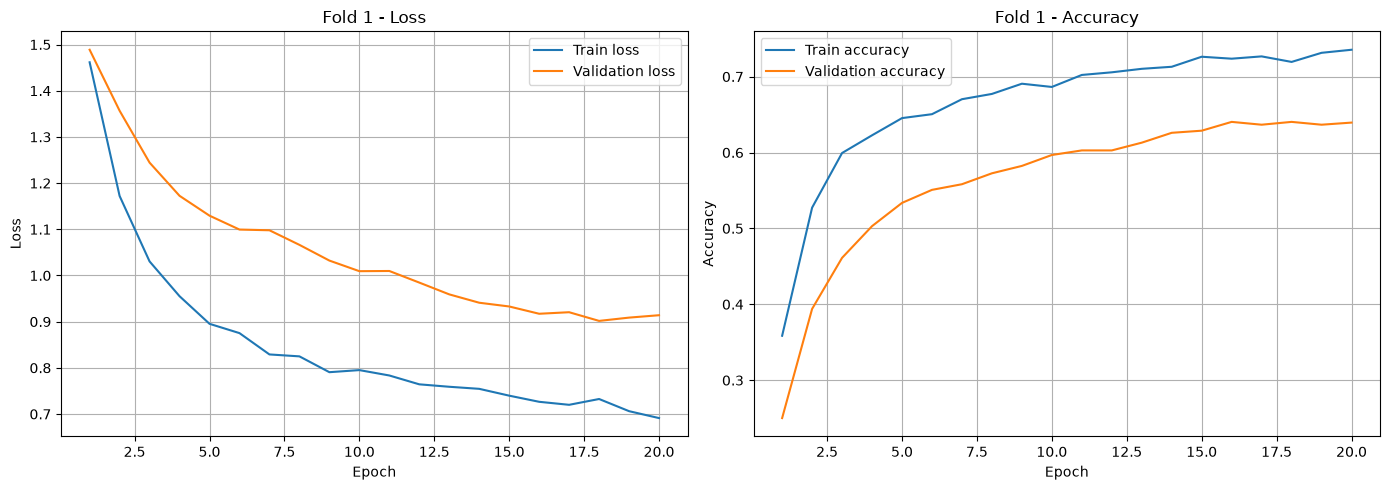

Fold 1: accuracy=0.8182, macro F1=0.8600

========== FOLD 2 ==========
Epoch 5/20 | train_loss=0.9042 | val_loss=1.2905 | train_acc=0.6418 | val_acc=0.4100
Epoch 10/20 | train_loss=0.7965 | val_loss=1.3065 | train_acc=0.6831 | val_acc=0.4363
Epoch 15/20 | train_loss=0.7387 | val_loss=1.4374 | train_acc=0.7083 | val_acc=0.4561
Epoch 20/20 | train_loss=0.6901 | val_loss=1.5838 | train_acc=0.7236 | val_acc=0.5208


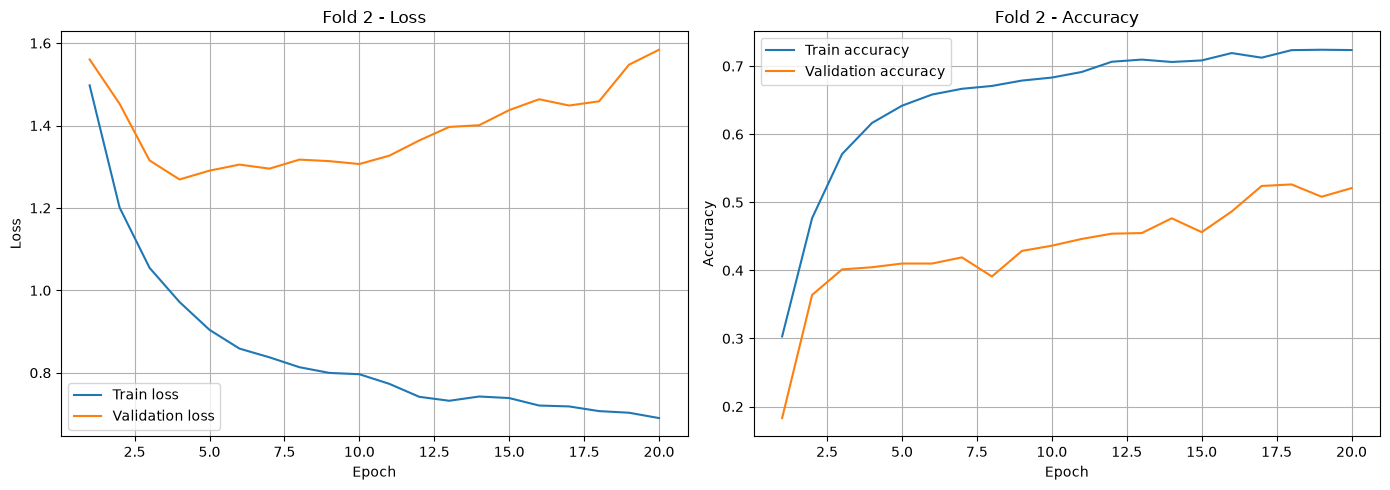

Fold 2: accuracy=0.7391, macro F1=0.5597

========== FOLD 3 ==========
Epoch 5/20 | train_loss=0.9682 | val_loss=2.2365 | train_acc=0.6023 | val_acc=0.4305
Epoch 10/20 | train_loss=0.8374 | val_loss=4.4190 | train_acc=0.6562 | val_acc=0.4659
Epoch 15/20 | train_loss=0.7756 | val_loss=7.2136 | train_acc=0.6967 | val_acc=0.5086
Epoch 20/20 | train_loss=0.7236 | val_loss=10.2899 | train_acc=0.7227 | val_acc=0.5677


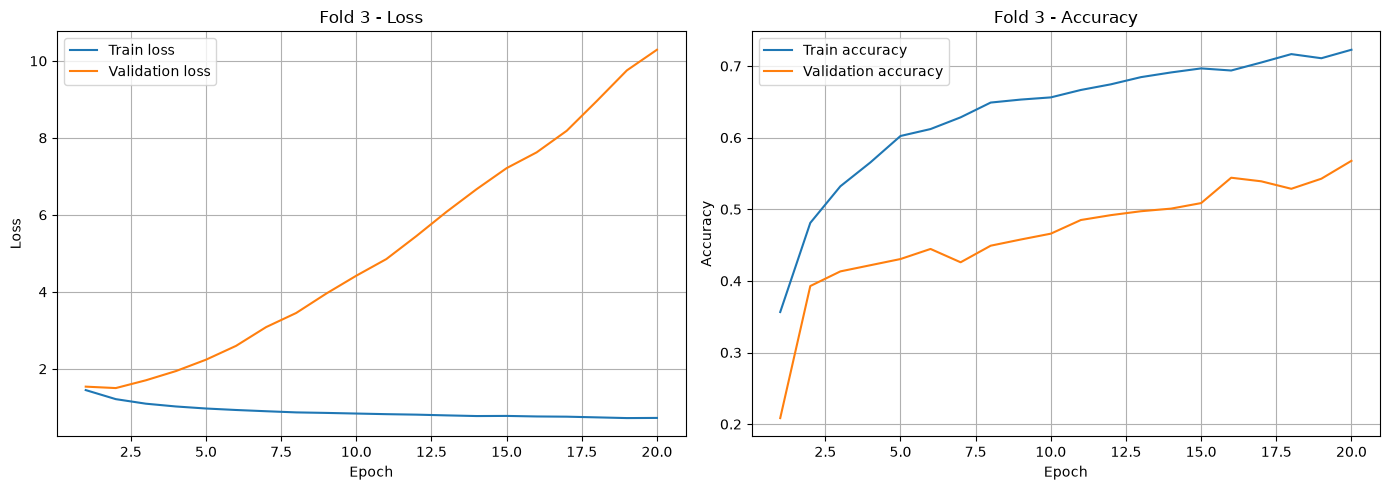

Fold 3: accuracy=0.6522, macro F1=0.5072

========== FOLD 4 ==========
Epoch 5/20 | train_loss=0.8778 | val_loss=1.9109 | train_acc=0.6572 | val_acc=0.3936
Epoch 10/20 | train_loss=0.7629 | val_loss=2.3649 | train_acc=0.7099 | val_acc=0.4446
Epoch 15/20 | train_loss=0.6772 | val_loss=2.8675 | train_acc=0.7464 | val_acc=0.4965
Epoch 20/20 | train_loss=0.6486 | val_loss=3.3014 | train_acc=0.7594 | val_acc=0.5052


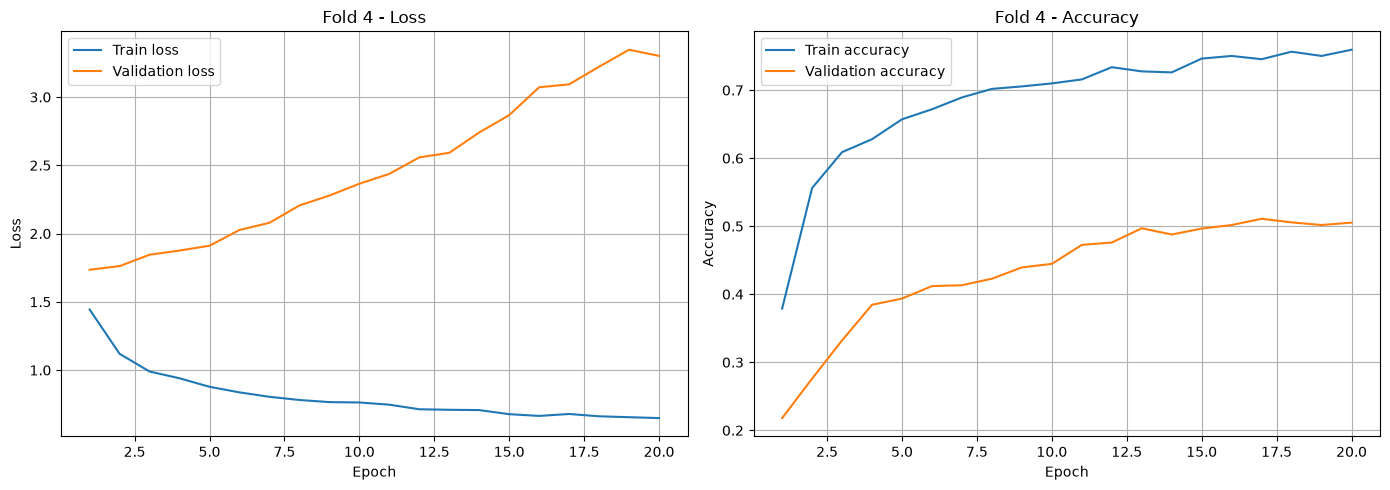

Fold 4: accuracy=0.6818, macro F1=0.5475

========== FOLD 5 ==========
Epoch 5/20 | train_loss=0.8722 | val_loss=1.2054 | train_acc=0.6707 | val_acc=0.4774
Epoch 10/20 | train_loss=0.7558 | val_loss=1.1122 | train_acc=0.7196 | val_acc=0.5285
Epoch 15/20 | train_loss=0.6983 | val_loss=1.0859 | train_acc=0.7439 | val_acc=0.5566
Epoch 20/20 | train_loss=0.6665 | val_loss=1.1269 | train_acc=0.7536 | val_acc=0.5521


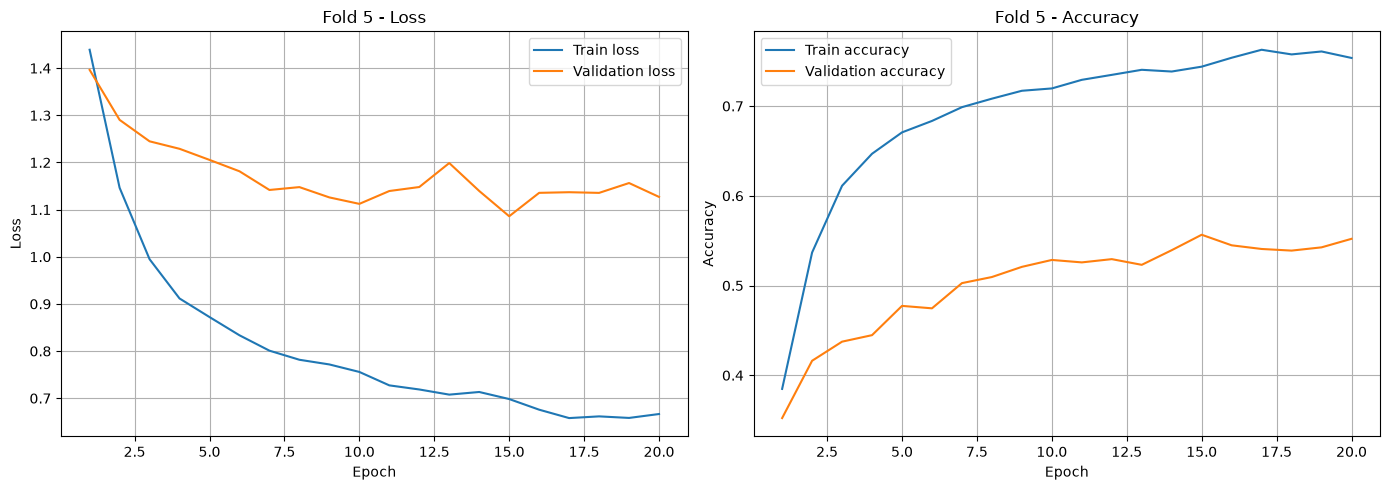

Fold 5: accuracy=0.6957, macro F1=0.6545

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.7174
Mean macro F1: 0.6258
              precision    recall  f1-score   support

        Bach       1.00      0.83      0.91        30
   Beethoven       0.84      0.69      0.76        55
      Brahms       0.36      0.50      0.42         8
      Mozart       0.33      0.64      0.44        11
    Schubert       0.64      0.78      0.70         9

    accuracy                           0.72       113
   macro avg       0.64      0.69      0.65       113
weighted avg       0.79      0.72      0.74       113



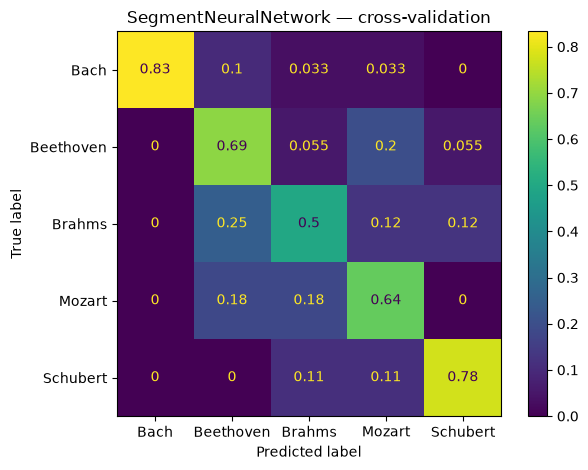

In [6]:
results_segment = cross_validate_feature_model(
    SegmentNeuralNetwork,
    X, y, groups,
    epochs=20,
    batch_size=64,
    learning_rate=0.001,
)

<span style="font-size:20px">
Mozemo primijetiti znacajno preprilagodjavanje modela neuronske mreze cak i sa ovako malim brojem parametrima, mozemo probati pristup sa dodatnim smanjenjem mreze ili da uvedemo vecu regularizaciju, ili oboje. 
</span>

In [7]:
class SegmentNeuralNetworkRegularized(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


SegmentNeuralNetworkRegularized | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/20 | train_loss=1.1631 | val_loss=1.2159 | train_acc=0.5264 | val_acc=0.4320
Epoch 10/20 | train_loss=1.0589 | val_loss=1.1297 | train_acc=0.5676 | val_acc=0.4404
Epoch 15/20 | train_loss=1.0048 | val_loss=1.0899 | train_acc=0.5895 | val_acc=0.4933
Epoch 20/20 | train_loss=0.9493 | val_loss=1.0893 | train_acc=0.6097 | val_acc=0.5049


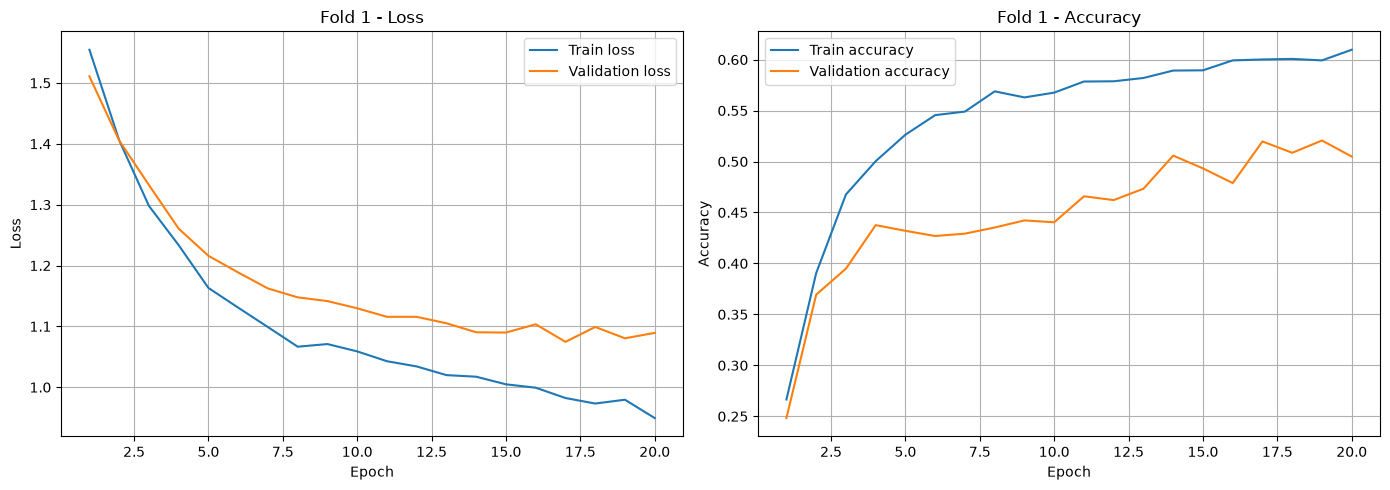

Fold 1: accuracy=0.6818, macro F1=0.6850

========== FOLD 2 ==========
Epoch 5/20 | train_loss=1.1484 | val_loss=1.2249 | train_acc=0.5192 | val_acc=0.3599
Epoch 10/20 | train_loss=1.0574 | val_loss=1.2527 | train_acc=0.5637 | val_acc=0.3969
Epoch 15/20 | train_loss=1.0203 | val_loss=1.4419 | train_acc=0.5790 | val_acc=0.4236
Epoch 20/20 | train_loss=0.9792 | val_loss=1.4772 | train_acc=0.6076 | val_acc=0.4412


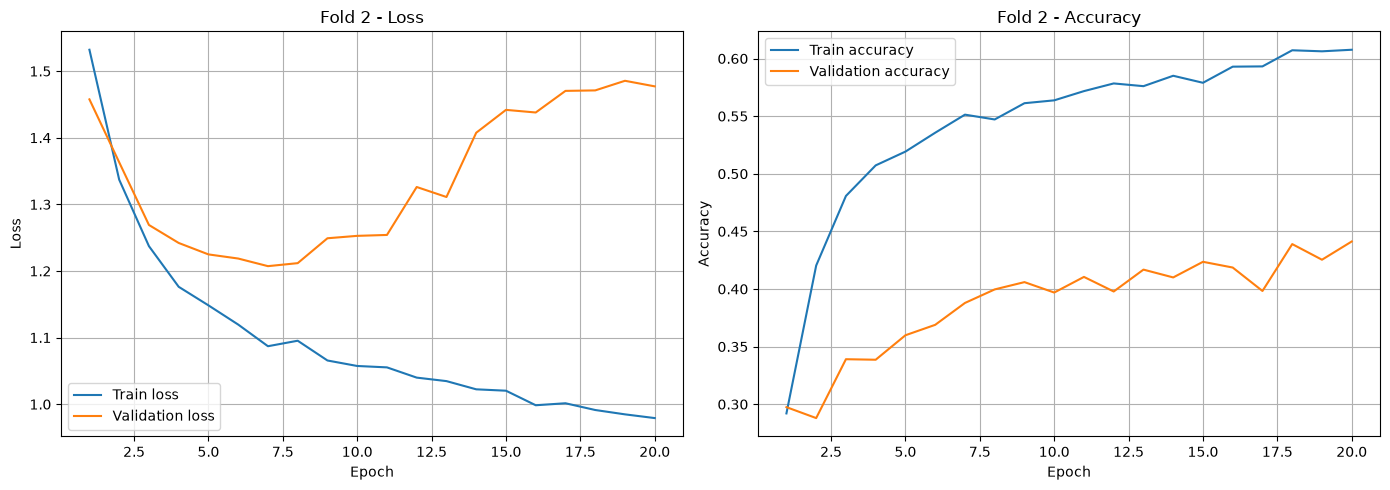

Fold 2: accuracy=0.6957, macro F1=0.6283

========== FOLD 3 ==========
Epoch 5/20 | train_loss=1.1836 | val_loss=1.8696 | train_acc=0.4830 | val_acc=0.4260
Epoch 10/20 | train_loss=1.0963 | val_loss=3.7753 | train_acc=0.5205 | val_acc=0.4827
Epoch 15/20 | train_loss=1.0281 | val_loss=7.0052 | train_acc=0.5872 | val_acc=0.4691
Epoch 20/20 | train_loss=0.9847 | val_loss=10.4518 | train_acc=0.6154 | val_acc=0.4959


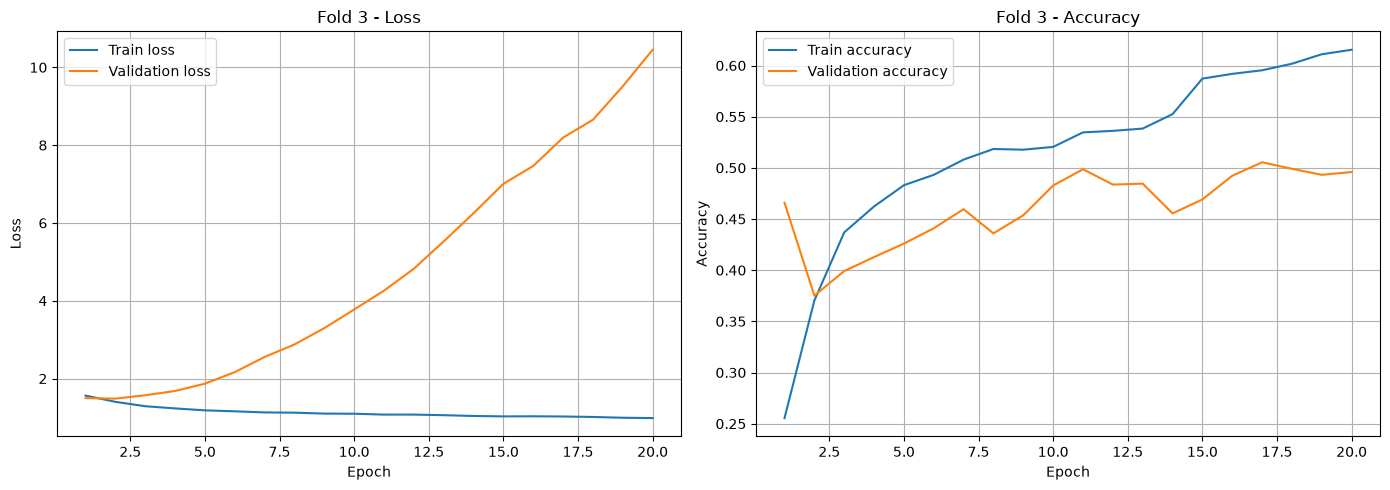

Fold 3: accuracy=0.4348, macro F1=0.3762

========== FOLD 4 ==========
Epoch 5/20 | train_loss=1.1394 | val_loss=1.5051 | train_acc=0.5509 | val_acc=0.3099
Epoch 10/20 | train_loss=1.0320 | val_loss=1.6383 | train_acc=0.5961 | val_acc=0.3522
Epoch 15/20 | train_loss=0.9783 | val_loss=1.8457 | train_acc=0.6244 | val_acc=0.3731
Epoch 20/20 | train_loss=0.9590 | val_loss=2.1219 | train_acc=0.6268 | val_acc=0.4455


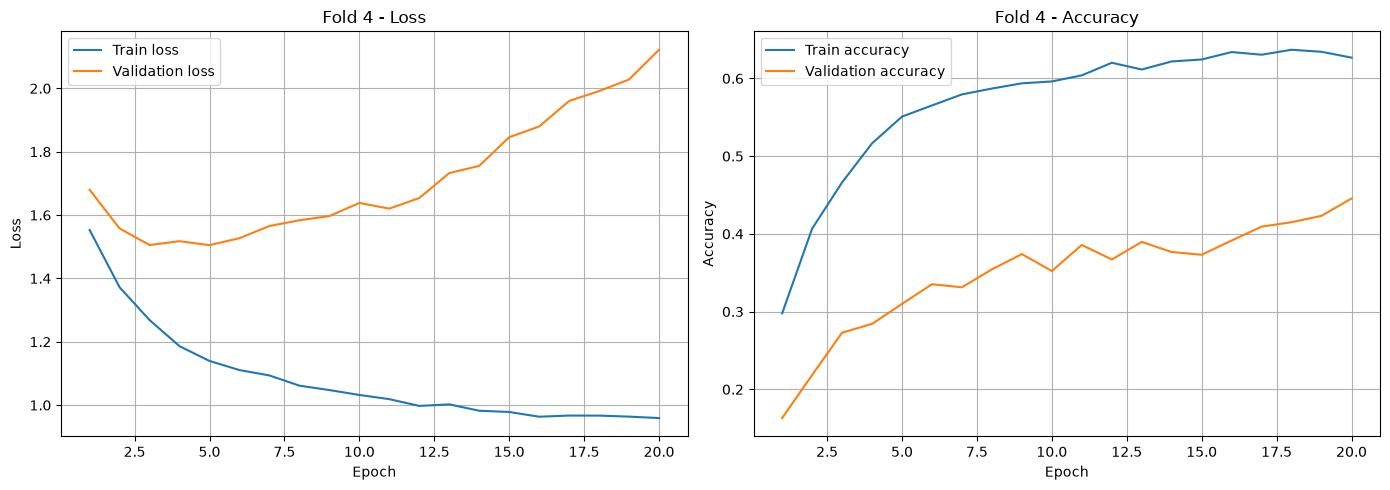

Fold 4: accuracy=0.5909, macro F1=0.4563

========== FOLD 5 ==========
Epoch 5/20 | train_loss=1.1315 | val_loss=1.2142 | train_acc=0.5250 | val_acc=0.4805
Epoch 10/20 | train_loss=1.0367 | val_loss=1.1565 | train_acc=0.5744 | val_acc=0.4932
Epoch 15/20 | train_loss=0.9787 | val_loss=1.1243 | train_acc=0.6076 | val_acc=0.5195
Epoch 20/20 | train_loss=0.9541 | val_loss=1.1174 | train_acc=0.6252 | val_acc=0.5190


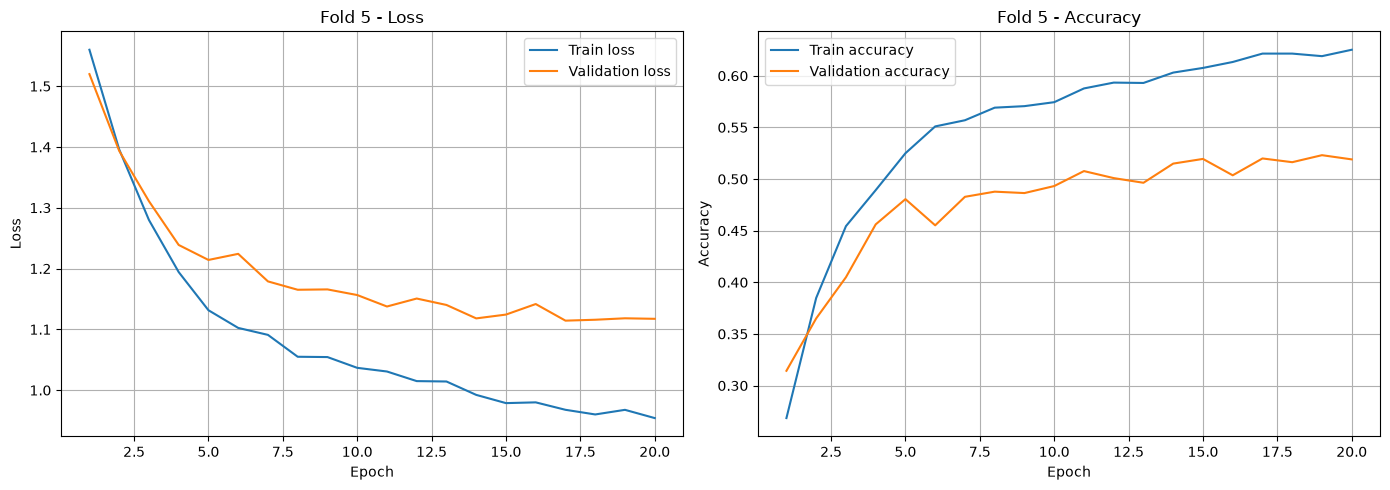

Fold 5: accuracy=0.6087, macro F1=0.5794

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.6024
Mean macro F1: 0.5450
              precision    recall  f1-score   support

        Bach       0.90      0.87      0.88        30
   Beethoven       0.88      0.42      0.57        55
      Brahms       0.38      0.62      0.48         8
      Mozart       0.32      0.73      0.44        11
    Schubert       0.30      0.67      0.41         9

    accuracy                           0.60       113
   macro avg       0.56      0.66      0.56       113
weighted avg       0.75      0.60      0.62       113



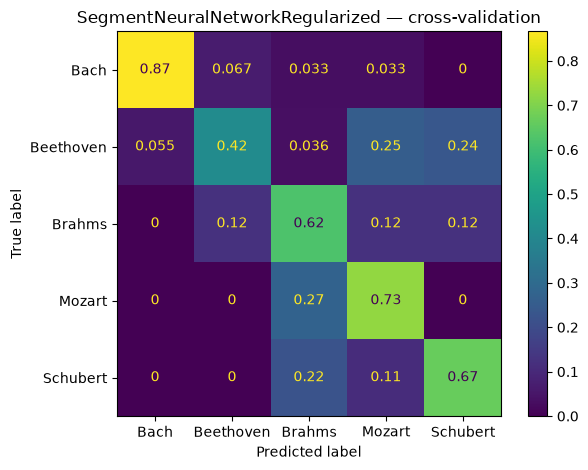

In [8]:
results_regularized = cross_validate_feature_model(
    SegmentNeuralNetworkRegularized,
    X, y, groups,
    epochs=20,
    batch_size=64,
    learning_rate=0.001,
)

In [9]:
class SmallSegmentNeuralNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


SmallSegmentNeuralNetwork | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/20 | train_loss=0.9478 | val_loss=1.1341 | train_acc=0.6275 | val_acc=0.4858
Epoch 10/20 | train_loss=0.8346 | val_loss=1.0185 | train_acc=0.6886 | val_acc=0.5689
Epoch 15/20 | train_loss=0.7584 | val_loss=0.9844 | train_acc=0.7170 | val_acc=0.5819
Epoch 20/20 | train_loss=0.7507 | val_loss=1.0018 | train_acc=0.7139 | val_acc=0.5930


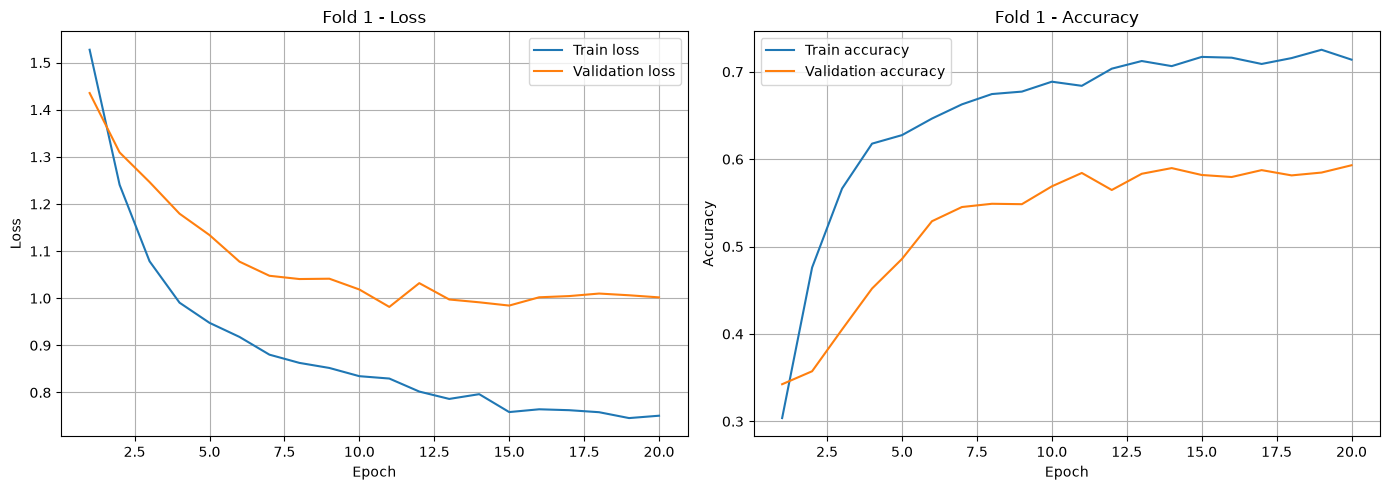

Fold 1: accuracy=0.7273, macro F1=0.6889

========== FOLD 2 ==========
Epoch 5/20 | train_loss=0.9456 | val_loss=1.2257 | train_acc=0.6023 | val_acc=0.4751
Epoch 10/20 | train_loss=0.8056 | val_loss=1.2403 | train_acc=0.6907 | val_acc=0.5511
Epoch 15/20 | train_loss=0.7432 | val_loss=1.3666 | train_acc=0.7039 | val_acc=0.5692
Epoch 20/20 | train_loss=0.7143 | val_loss=1.4568 | train_acc=0.7151 | val_acc=0.5841


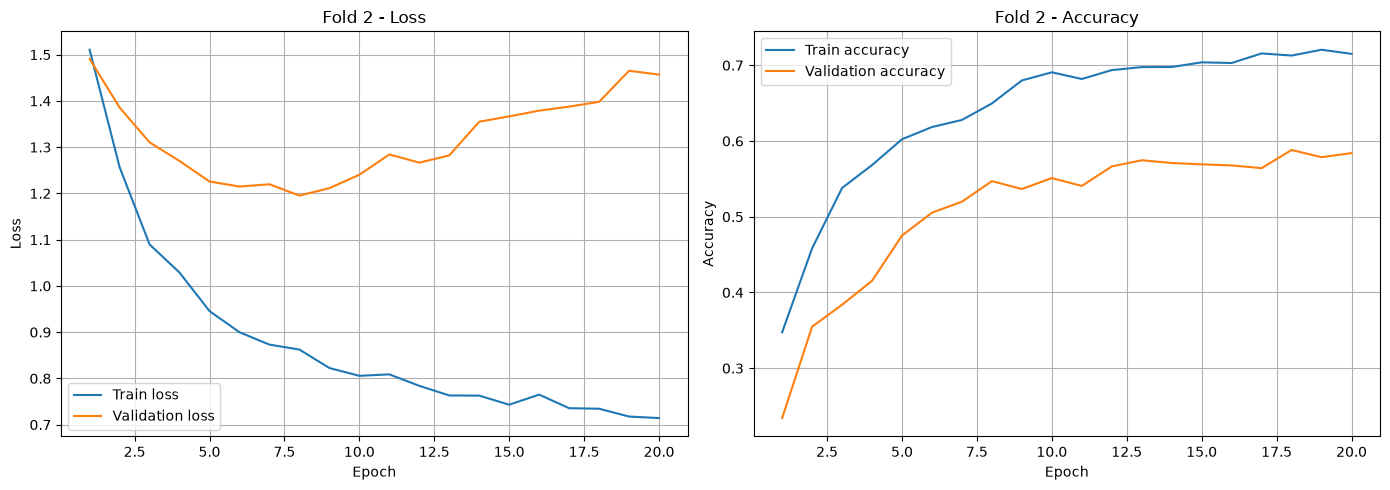

Fold 2: accuracy=0.6957, macro F1=0.5255

========== FOLD 3 ==========
Epoch 5/20 | train_loss=1.0236 | val_loss=2.4813 | train_acc=0.5620 | val_acc=0.4550
Epoch 10/20 | train_loss=0.8741 | val_loss=4.2647 | train_acc=0.6172 | val_acc=0.5218
Epoch 15/20 | train_loss=0.8092 | val_loss=6.1087 | train_acc=0.6580 | val_acc=0.5668
Epoch 20/20 | train_loss=0.7803 | val_loss=8.1660 | train_acc=0.6602 | val_acc=0.5740


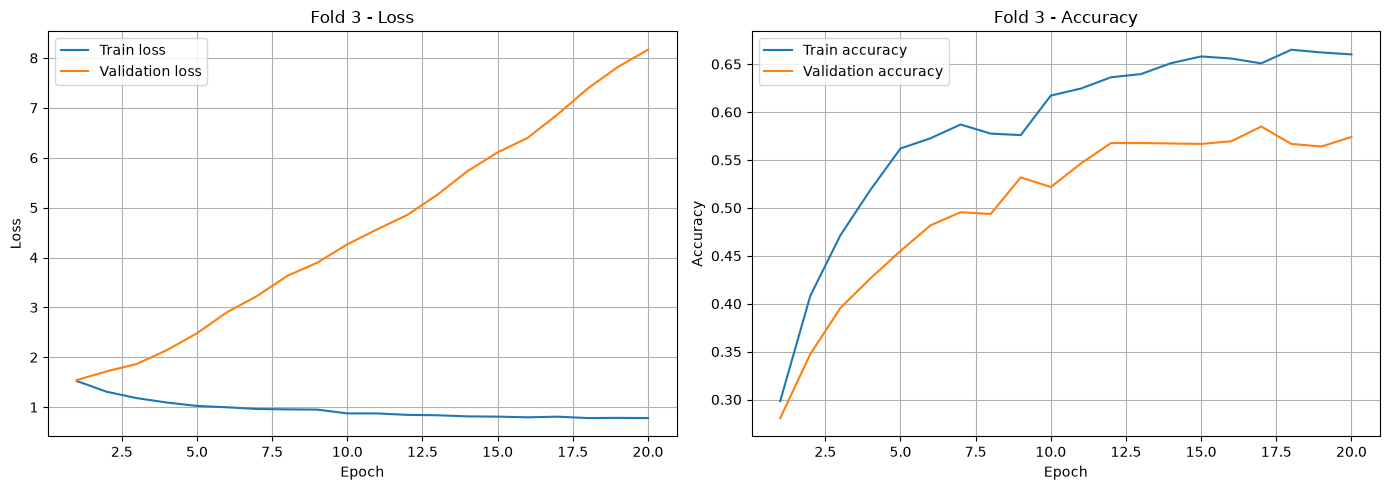

Fold 3: accuracy=0.6957, macro F1=0.5499

========== FOLD 4 ==========
Epoch 5/20 | train_loss=0.9498 | val_loss=1.5571 | train_acc=0.6069 | val_acc=0.3627
Epoch 10/20 | train_loss=0.8446 | val_loss=1.8445 | train_acc=0.6247 | val_acc=0.4063
Epoch 15/20 | train_loss=0.8011 | val_loss=2.4422 | train_acc=0.6495 | val_acc=0.4128
Epoch 20/20 | train_loss=0.7625 | val_loss=3.1899 | train_acc=0.6645 | val_acc=0.4202


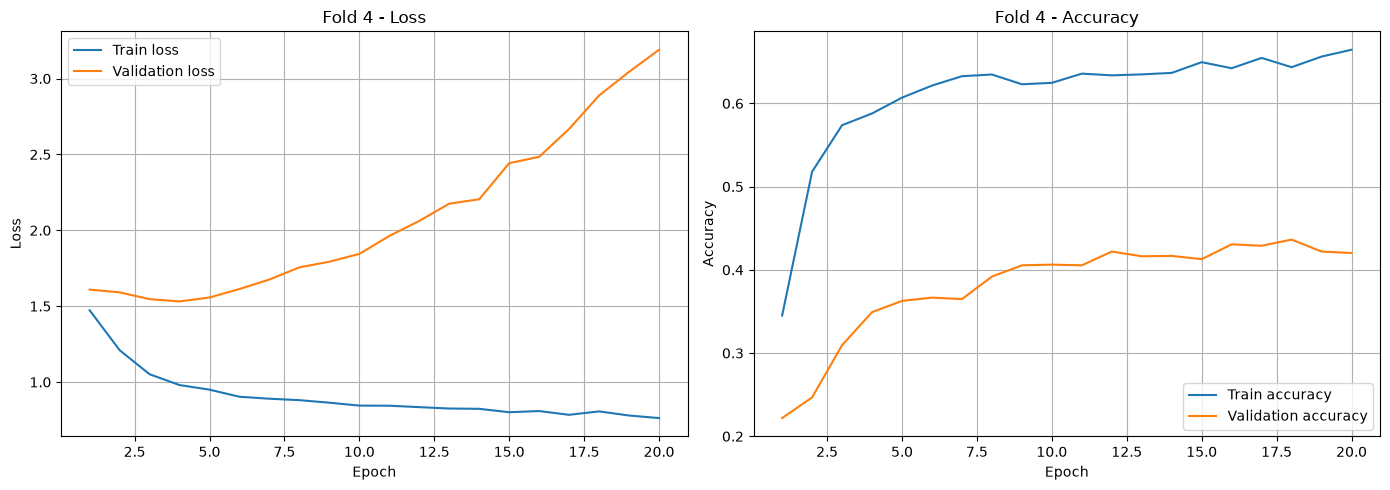

Fold 4: accuracy=0.5000, macro F1=0.4100

========== FOLD 5 ==========
Epoch 5/20 | train_loss=0.9448 | val_loss=1.1737 | train_acc=0.5905 | val_acc=0.4819
Epoch 10/20 | train_loss=0.8197 | val_loss=1.1026 | train_acc=0.6430 | val_acc=0.4982
Epoch 15/20 | train_loss=0.7688 | val_loss=1.1279 | train_acc=0.6641 | val_acc=0.5009
Epoch 20/20 | train_loss=0.7273 | val_loss=1.1099 | train_acc=0.6840 | val_acc=0.5177


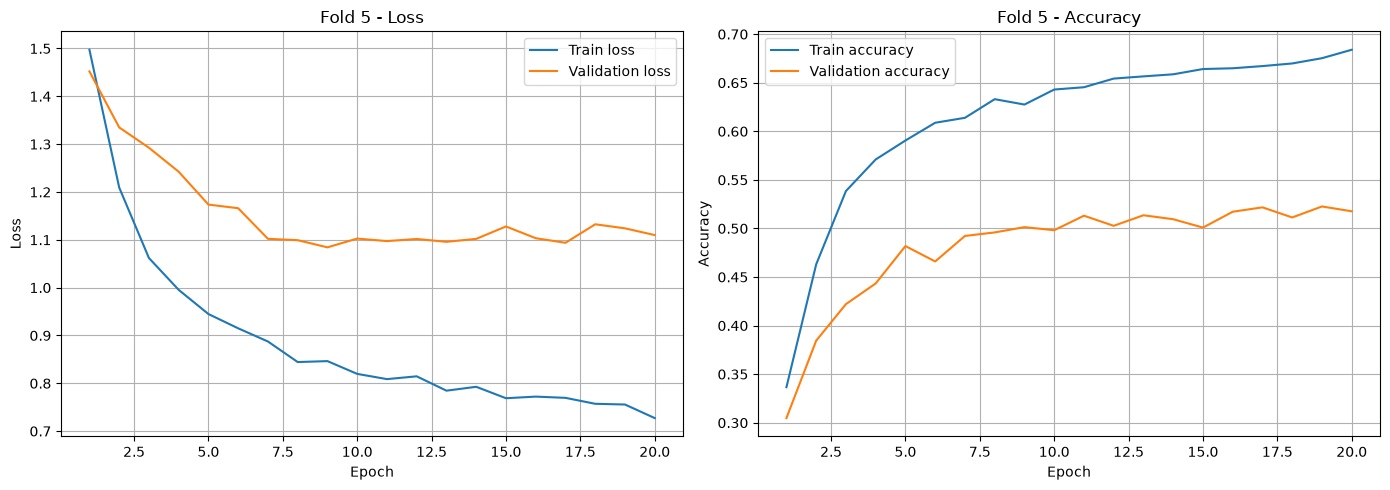

Fold 5: accuracy=0.6522, macro F1=0.6139

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.6542
Mean macro F1: 0.5576
              precision    recall  f1-score   support

        Bach       1.00      0.83      0.91        30
   Beethoven       0.85      0.60      0.70        55
      Brahms       0.19      0.38      0.25         8
      Mozart       0.37      0.64      0.47        11
    Schubert       0.43      0.67      0.52         9

    accuracy                           0.65       113
   macro avg       0.57      0.62      0.57       113
weighted avg       0.76      0.65      0.69       113



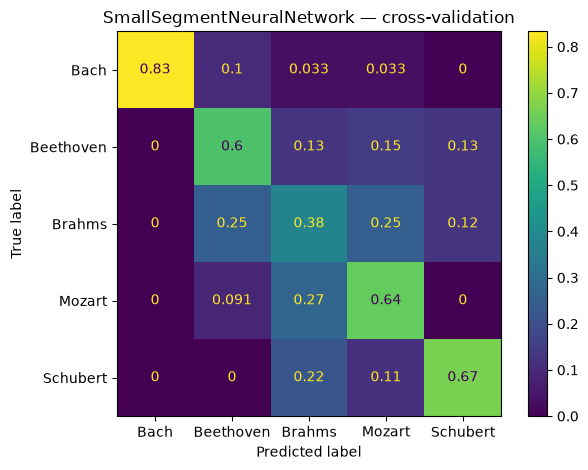

In [10]:
results_small_segment = cross_validate_feature_model(
    SmallSegmentNeuralNetwork,
    X, y, groups,
    epochs=20,
    batch_size=64,
    learning_rate=0.001,
)

<span style="font-size:20px">
Naime, nijedan od navedenih pristupa nije urodio plodom, u svakom slucaju se neuronska mreza preprilagodjavala. Mozemo pokusati sada klasifikaciju gdje akumuliramo feature vektore svih segmenata u jedan feature vektor koji ce da koristi cijela kompozicija
</span>

In [11]:
X_work, y_work, work_ids = make_work_level_dataset(X,y,groups)

In [12]:
class WorkNN_Small(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.network(x)


WorkNN_Small | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/30 | train_loss=1.4893 | val_loss=1.5027 | train_acc=0.3000 | val_acc=0.3043
Epoch 10/30 | train_loss=1.1454 | val_loss=1.1889 | train_acc=0.7111 | val_acc=0.6522
Epoch 15/30 | train_loss=0.8185 | val_loss=0.9485 | train_acc=0.7778 | val_acc=0.8261
Epoch 20/30 | train_loss=0.7335 | val_loss=0.8314 | train_acc=0.7444 | val_acc=0.7826
Epoch 25/30 | train_loss=0.6661 | val_loss=0.7853 | train_acc=0.8222 | val_acc=0.7826
Epoch 30/30 | train_loss=0.5232 | val_loss=0.7452 | train_acc=0.8556 | val_acc=0.7826


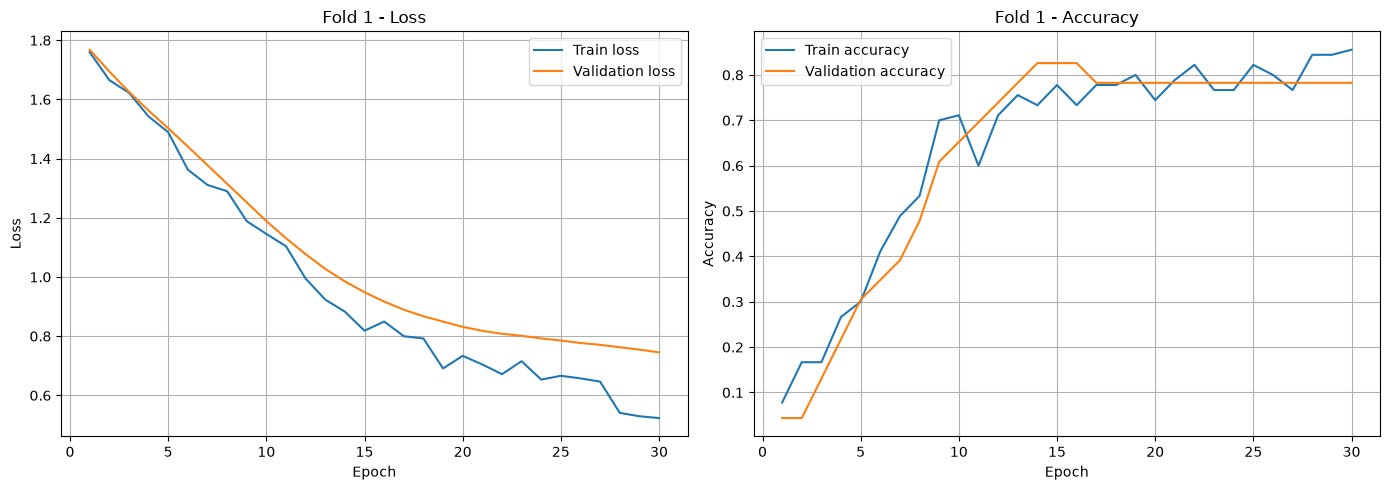

Fold 1: accuracy=0.7826, macro F1=0.4963

========== FOLD 2 ==========
Epoch 5/30 | train_loss=1.1752 | val_loss=1.1933 | train_acc=0.6889 | val_acc=0.7391
Epoch 10/30 | train_loss=0.8953 | val_loss=1.0277 | train_acc=0.7333 | val_acc=0.7391
Epoch 15/30 | train_loss=0.7518 | val_loss=0.9632 | train_acc=0.7333 | val_acc=0.7391
Epoch 20/30 | train_loss=0.7266 | val_loss=0.9204 | train_acc=0.7444 | val_acc=0.6957
Epoch 25/30 | train_loss=0.6002 | val_loss=0.8976 | train_acc=0.8444 | val_acc=0.7391
Epoch 30/30 | train_loss=0.4782 | val_loss=0.8825 | train_acc=0.8333 | val_acc=0.7391


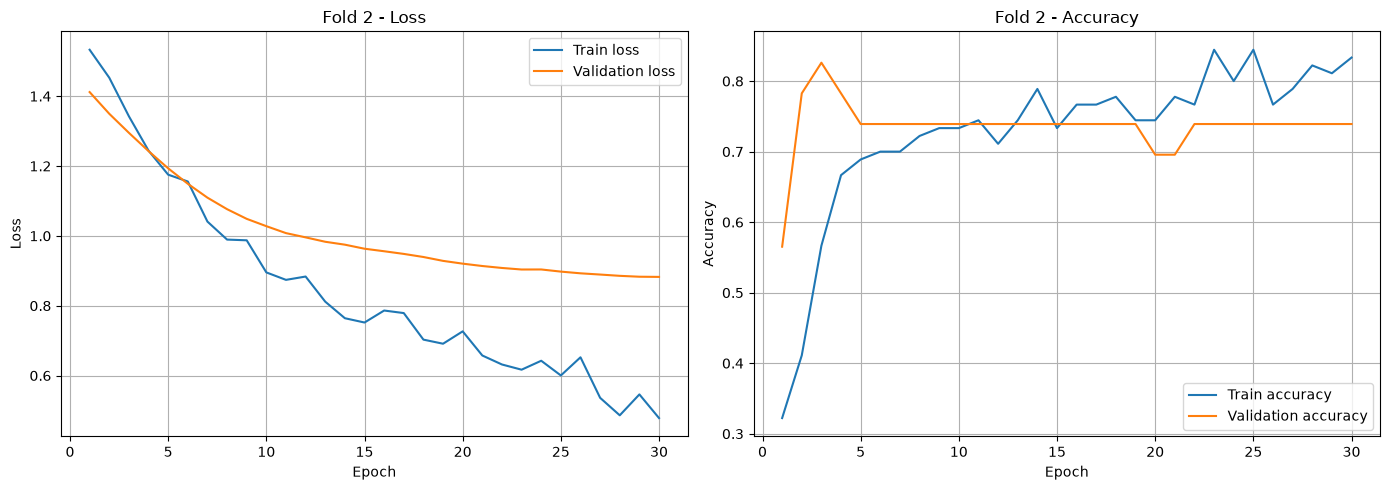

Fold 2: accuracy=0.7391, macro F1=0.4446

========== FOLD 3 ==========
Epoch 5/30 | train_loss=1.5316 | val_loss=1.5320 | train_acc=0.2222 | val_acc=0.2609
Epoch 10/30 | train_loss=1.2182 | val_loss=1.2366 | train_acc=0.5111 | val_acc=0.5652
Epoch 15/30 | train_loss=1.0257 | val_loss=0.9873 | train_acc=0.7000 | val_acc=0.6957
Epoch 20/30 | train_loss=0.8050 | val_loss=0.8431 | train_acc=0.7778 | val_acc=0.7826
Epoch 25/30 | train_loss=0.7546 | val_loss=0.7800 | train_acc=0.8000 | val_acc=0.7826
Epoch 30/30 | train_loss=0.6907 | val_loss=0.7454 | train_acc=0.8111 | val_acc=0.7826


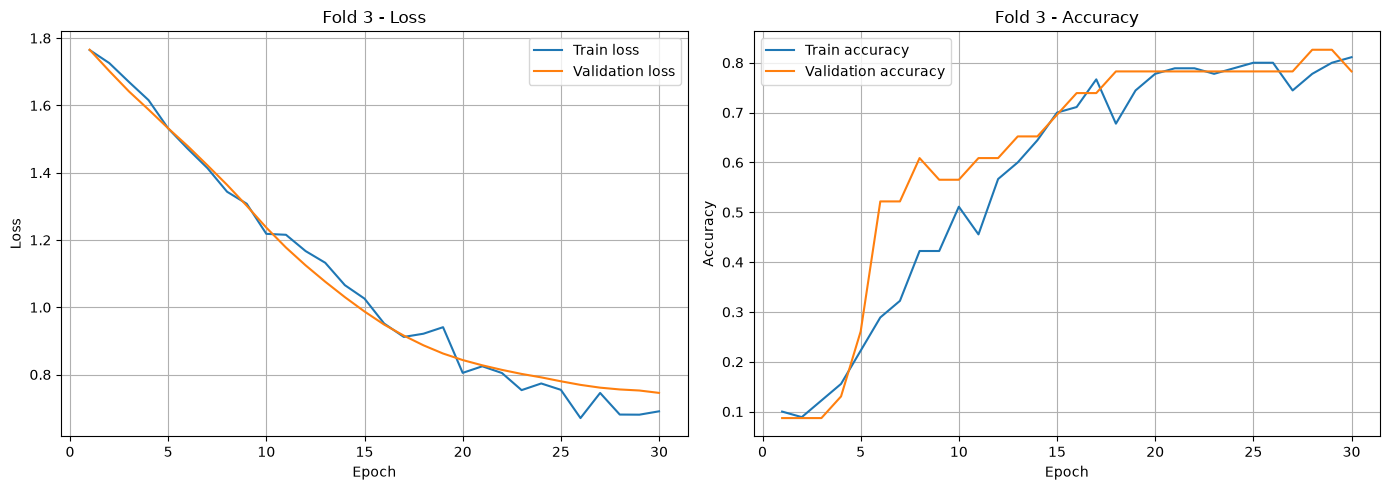

Fold 3: accuracy=0.7826, macro F1=0.4939

========== FOLD 4 ==========
Epoch 5/30 | train_loss=1.2757 | val_loss=1.2475 | train_acc=0.5604 | val_acc=0.7727
Epoch 10/30 | train_loss=0.9737 | val_loss=0.9826 | train_acc=0.7582 | val_acc=0.7273
Epoch 15/30 | train_loss=0.8080 | val_loss=0.8426 | train_acc=0.8132 | val_acc=0.7273
Epoch 20/30 | train_loss=0.6956 | val_loss=0.7755 | train_acc=0.7363 | val_acc=0.7727
Epoch 25/30 | train_loss=0.6077 | val_loss=0.7436 | train_acc=0.7802 | val_acc=0.7273
Epoch 30/30 | train_loss=0.5041 | val_loss=0.7319 | train_acc=0.8242 | val_acc=0.6818


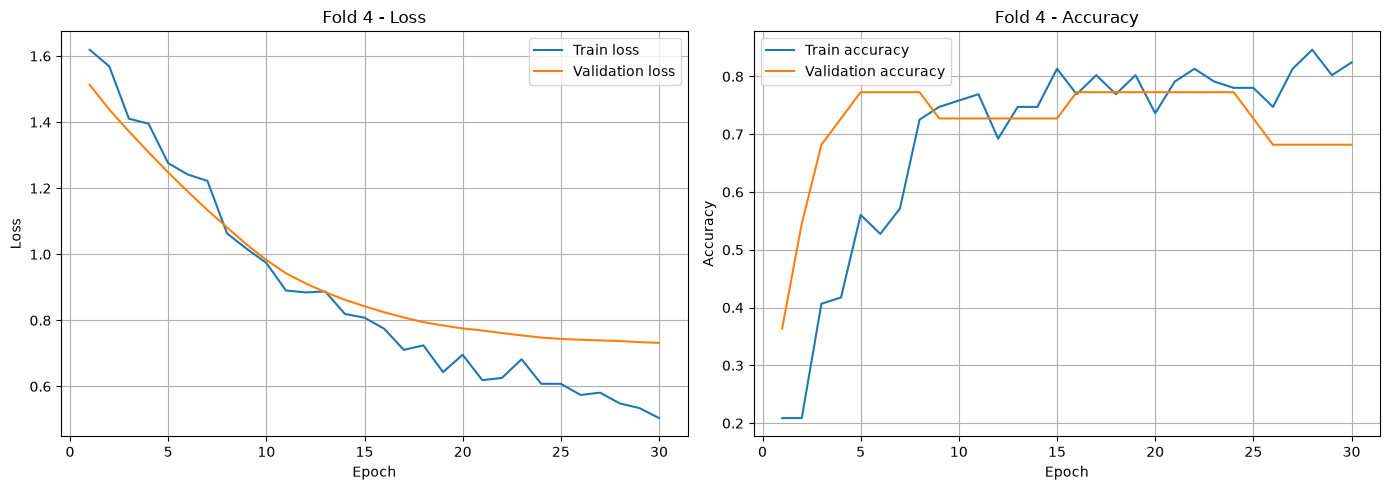

Fold 4: accuracy=0.6818, macro F1=0.3286

========== FOLD 5 ==========
Epoch 5/30 | train_loss=1.2152 | val_loss=1.2133 | train_acc=0.6813 | val_acc=0.7727
Epoch 10/30 | train_loss=0.9377 | val_loss=0.9064 | train_acc=0.7802 | val_acc=0.7727
Epoch 15/30 | train_loss=0.7919 | val_loss=0.7587 | train_acc=0.7473 | val_acc=0.7727
Epoch 20/30 | train_loss=0.6659 | val_loss=0.6885 | train_acc=0.7912 | val_acc=0.7727
Epoch 25/30 | train_loss=0.6247 | val_loss=0.6438 | train_acc=0.7692 | val_acc=0.7727
Epoch 30/30 | train_loss=0.6125 | val_loss=0.6213 | train_acc=0.8132 | val_acc=0.7727


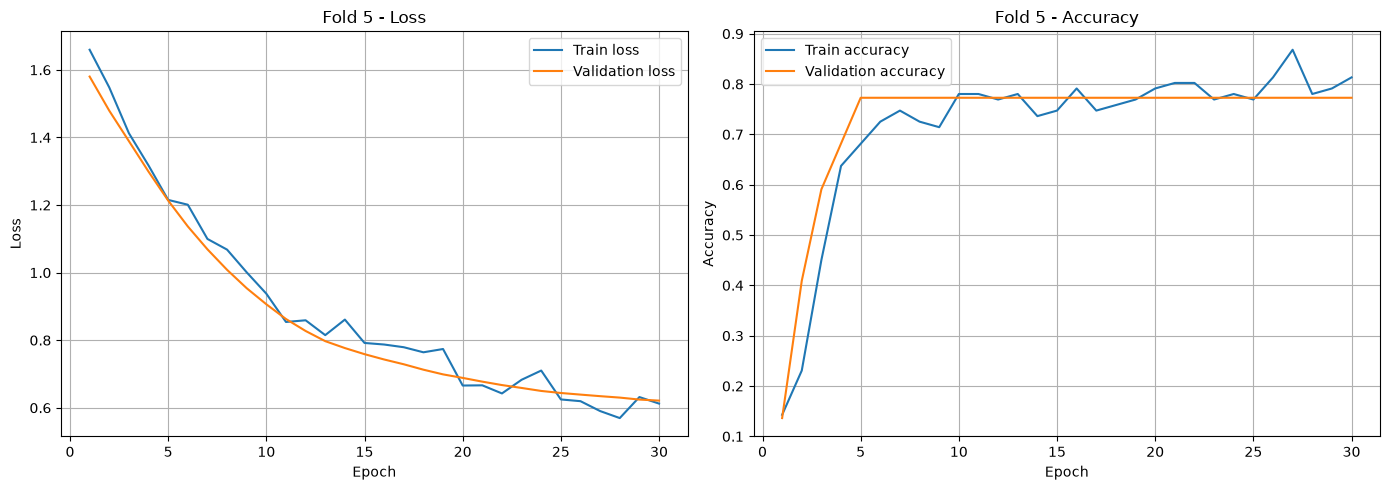

Fold 5: accuracy=0.7727, macro F1=0.4385

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.7518
Mean macro F1: 0.4404
              precision    recall  f1-score   support

        Bach       0.88      1.00      0.94        30
   Beethoven       0.73      0.93      0.82        55
      Brahms       0.50      0.12      0.20         8
      Mozart       0.50      0.27      0.35        11
    Schubert       0.00      0.00      0.00         9

    accuracy                           0.75       113
   macro avg       0.52      0.47      0.46       113
weighted avg       0.67      0.75      0.69       113



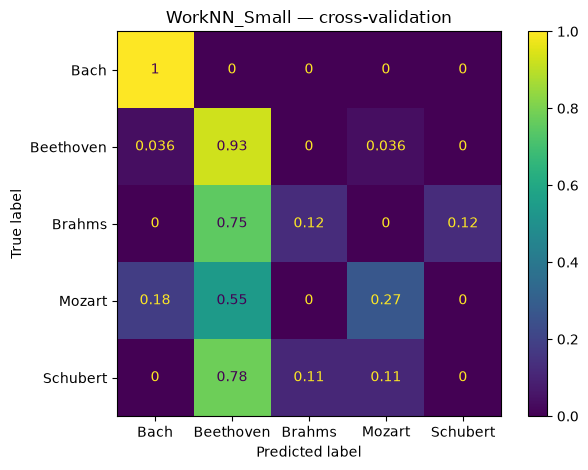

In [13]:
results_work_small = cross_validate_feature_model(
    WorkNN_Small,
    X_work, y_work,
    epochs=30,
    batch_size=16,
    learning_rate=0.001,
)

In [14]:
# Vidimo da smo uspjeli da poboljsamo rezultate po pitanju preprilagodjavanja

In [15]:
class WorkNN_Compact(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


WorkNN_Compact | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/60 | train_loss=1.4474 | val_loss=1.4297 | train_acc=0.3667 | val_acc=0.3043
Epoch 10/60 | train_loss=1.2715 | val_loss=1.2176 | train_acc=0.5222 | val_acc=0.6087
Epoch 15/60 | train_loss=1.1487 | val_loss=1.0524 | train_acc=0.5778 | val_acc=0.6957
Epoch 20/60 | train_loss=1.0201 | val_loss=0.9324 | train_acc=0.6889 | val_acc=0.7826
Epoch 25/60 | train_loss=0.9075 | val_loss=0.8655 | train_acc=0.7000 | val_acc=0.7826
Epoch 30/60 | train_loss=0.8472 | val_loss=0.8167 | train_acc=0.7000 | val_acc=0.7826
Epoch 35/60 | train_loss=0.7658 | val_loss=0.7856 | train_acc=0.6889 | val_acc=0.7826
Epoch 40/60 | train_loss=0.7242 | val_loss=0.7620 | train_acc=0.6778 | val_acc=0.7826
Epoch 45/60 | train_loss=0.7127 | val_loss=0.7451 | train_acc=0.7556 | val_acc=0.7826
Epoch 50/60 | train_loss=0.7463 | val_loss=0.7311 | train_acc=0.7556 | val_acc=0.7826
Epoch 55/60 | train_lo

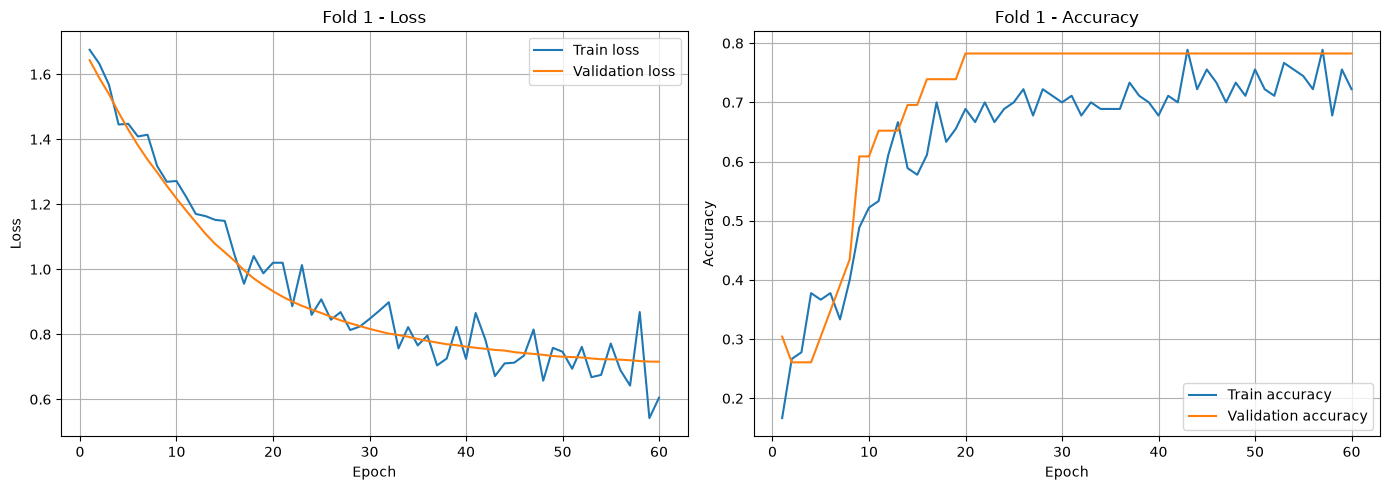

Fold 1: accuracy=0.7826, macro F1=0.4872

========== FOLD 2 ==========
Epoch 5/60 | train_loss=1.2643 | val_loss=1.2814 | train_acc=0.5333 | val_acc=0.4348
Epoch 10/60 | train_loss=1.0825 | val_loss=1.1751 | train_acc=0.5889 | val_acc=0.5217
Epoch 15/60 | train_loss=0.9236 | val_loss=1.1149 | train_acc=0.6444 | val_acc=0.5652
Epoch 20/60 | train_loss=0.8405 | val_loss=1.0679 | train_acc=0.6889 | val_acc=0.5652
Epoch 25/60 | train_loss=0.7767 | val_loss=1.0375 | train_acc=0.7111 | val_acc=0.5652
Epoch 30/60 | train_loss=0.7424 | val_loss=1.0241 | train_acc=0.7889 | val_acc=0.6087
Epoch 35/60 | train_loss=0.7841 | val_loss=1.0154 | train_acc=0.7333 | val_acc=0.6087
Epoch 40/60 | train_loss=0.7242 | val_loss=1.0137 | train_acc=0.7778 | val_acc=0.6087
Epoch 45/60 | train_loss=0.6882 | val_loss=0.9926 | train_acc=0.7444 | val_acc=0.6522
Epoch 50/60 | train_loss=0.7362 | val_loss=0.9891 | train_acc=0.7444 | val_acc=0.6522
Epoch 55/60 | train_loss=0.6726 | val_loss=0.9801 | train_acc=0.7556 |

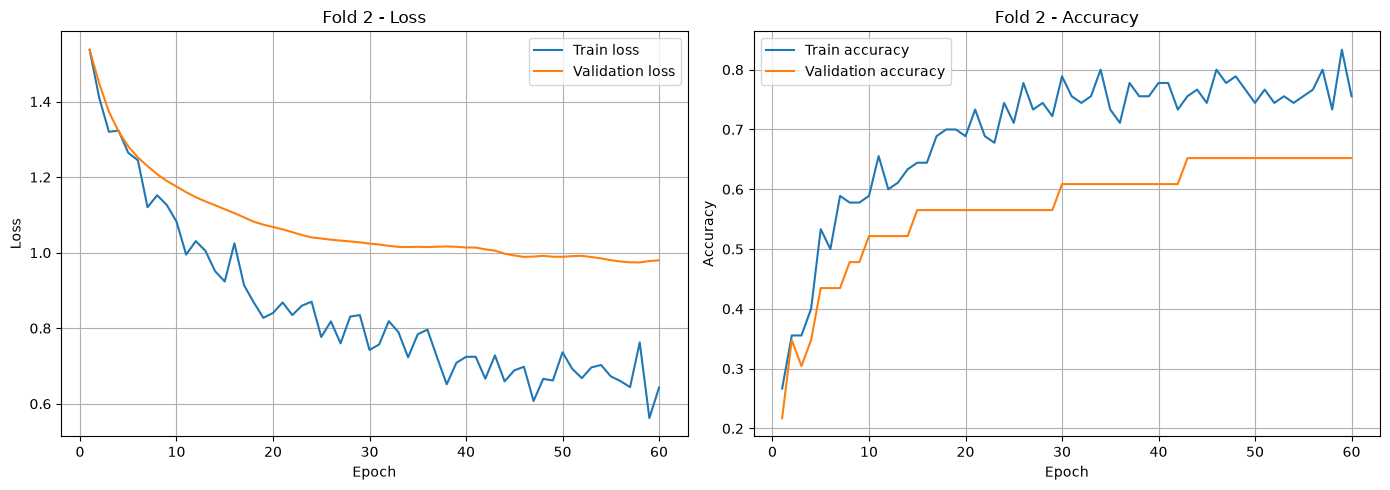

Fold 2: accuracy=0.6522, macro F1=0.3904

========== FOLD 3 ==========
Epoch 5/60 | train_loss=1.2774 | val_loss=1.2084 | train_acc=0.5667 | val_acc=0.6087
Epoch 10/60 | train_loss=1.0641 | val_loss=0.9897 | train_acc=0.6333 | val_acc=0.7391
Epoch 15/60 | train_loss=1.0135 | val_loss=0.8679 | train_acc=0.5889 | val_acc=0.7391
Epoch 20/60 | train_loss=0.8903 | val_loss=0.7983 | train_acc=0.6444 | val_acc=0.7391
Epoch 25/60 | train_loss=0.7981 | val_loss=0.7605 | train_acc=0.6667 | val_acc=0.7391
Epoch 30/60 | train_loss=0.7443 | val_loss=0.7344 | train_acc=0.7000 | val_acc=0.7391
Epoch 35/60 | train_loss=0.7614 | val_loss=0.7211 | train_acc=0.6556 | val_acc=0.7391
Epoch 40/60 | train_loss=0.7135 | val_loss=0.7117 | train_acc=0.7111 | val_acc=0.7391
Epoch 45/60 | train_loss=0.7256 | val_loss=0.6929 | train_acc=0.7111 | val_acc=0.7391
Epoch 50/60 | train_loss=0.6758 | val_loss=0.6783 | train_acc=0.7222 | val_acc=0.7391
Epoch 55/60 | train_loss=0.7287 | val_loss=0.6673 | train_acc=0.7000 |

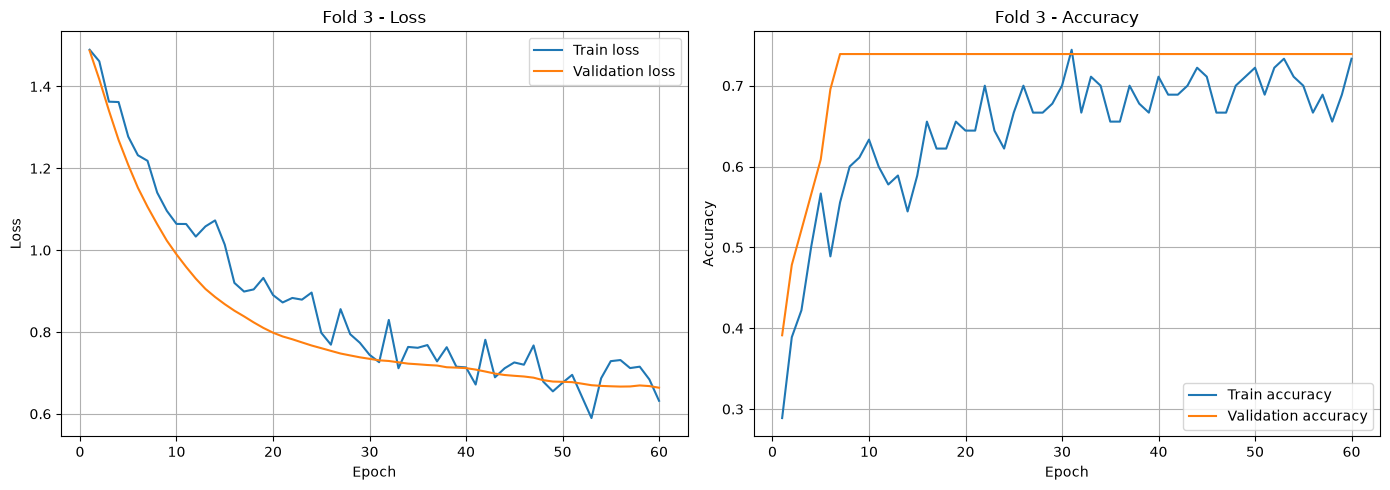

Fold 3: accuracy=0.7391, macro F1=0.3476

========== FOLD 4 ==========
Epoch 5/60 | train_loss=1.5737 | val_loss=1.5353 | train_acc=0.1319 | val_acc=0.1818
Epoch 10/60 | train_loss=1.2847 | val_loss=1.3521 | train_acc=0.3956 | val_acc=0.4091
Epoch 15/60 | train_loss=1.2476 | val_loss=1.1894 | train_acc=0.3956 | val_acc=0.7273
Epoch 20/60 | train_loss=1.0731 | val_loss=1.0513 | train_acc=0.5275 | val_acc=0.7273
Epoch 25/60 | train_loss=0.9807 | val_loss=0.9597 | train_acc=0.5495 | val_acc=0.7273
Epoch 30/60 | train_loss=0.9473 | val_loss=0.8991 | train_acc=0.5714 | val_acc=0.7727
Epoch 35/60 | train_loss=0.9189 | val_loss=0.8683 | train_acc=0.6484 | val_acc=0.7273
Epoch 40/60 | train_loss=0.7620 | val_loss=0.8293 | train_acc=0.6813 | val_acc=0.7273
Epoch 45/60 | train_loss=0.8349 | val_loss=0.8097 | train_acc=0.6044 | val_acc=0.6818
Epoch 50/60 | train_loss=0.8378 | val_loss=0.7863 | train_acc=0.5824 | val_acc=0.6818
Epoch 55/60 | train_loss=0.7399 | val_loss=0.7679 | train_acc=0.7033 |

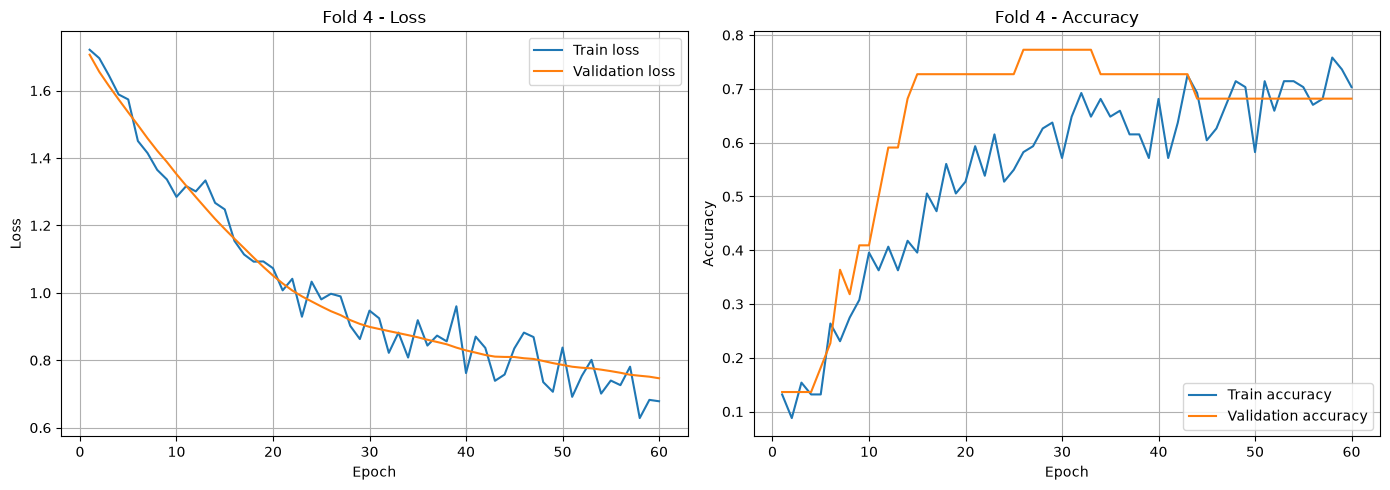

Fold 4: accuracy=0.6818, macro F1=0.3833

========== FOLD 5 ==========
Epoch 5/60 | train_loss=1.5808 | val_loss=1.5828 | train_acc=0.3297 | val_acc=0.2727
Epoch 10/60 | train_loss=1.3940 | val_loss=1.3681 | train_acc=0.4505 | val_acc=0.6364
Epoch 15/60 | train_loss=1.1738 | val_loss=1.1190 | train_acc=0.5824 | val_acc=0.6818
Epoch 20/60 | train_loss=1.1607 | val_loss=0.9401 | train_acc=0.5604 | val_acc=0.7727
Epoch 25/60 | train_loss=1.0442 | val_loss=0.8311 | train_acc=0.6374 | val_acc=0.7727
Epoch 30/60 | train_loss=1.0205 | val_loss=0.7558 | train_acc=0.5824 | val_acc=0.7727
Epoch 35/60 | train_loss=0.9793 | val_loss=0.6956 | train_acc=0.6264 | val_acc=0.7727
Epoch 40/60 | train_loss=0.7681 | val_loss=0.6575 | train_acc=0.7033 | val_acc=0.7727
Epoch 45/60 | train_loss=0.8261 | val_loss=0.6266 | train_acc=0.6813 | val_acc=0.8182
Epoch 50/60 | train_loss=0.8238 | val_loss=0.5878 | train_acc=0.6813 | val_acc=0.8182
Epoch 55/60 | train_loss=0.7829 | val_loss=0.5545 | train_acc=0.6813 |

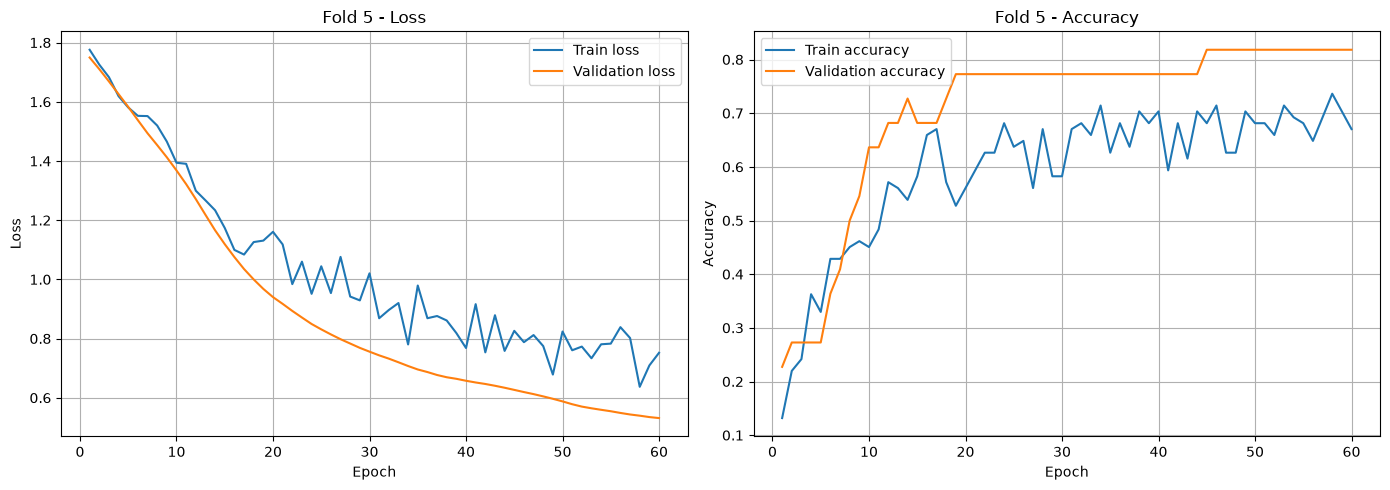

Fold 5: accuracy=0.8182, macro F1=0.5013

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.7348
Mean macro F1: 0.4220
              precision    recall  f1-score   support

        Bach       0.85      0.97      0.91        30
   Beethoven       0.72      0.91      0.81        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.38      0.27      0.32        11
    Schubert       1.00      0.11      0.20         9

    accuracy                           0.73       113
   macro avg       0.59      0.45      0.45       113
weighted avg       0.70      0.73      0.68       113



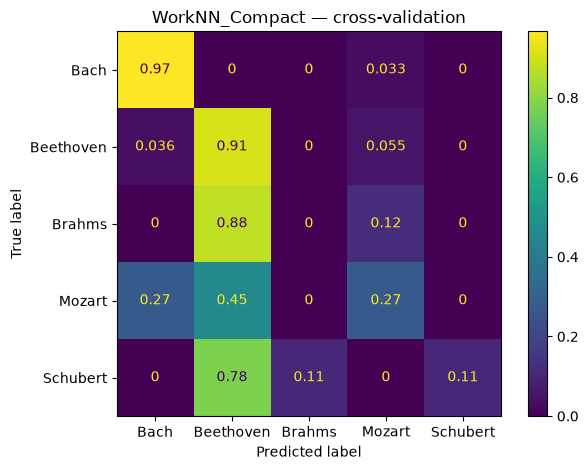

In [17]:
results_work_compact = cross_validate_feature_model(
    WorkNN_Compact,
    X_work, y_work,
    epochs=60,
    batch_size=16,
    learning_rate=0.001,
    weight_decay=1e-4,
)

Ovo je malo lose :(